In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [2]:
#oscillator constant
omega = 1.0

In [ ]:
def y_true(t,omega = 1.0):
    """
    Analytical solution for a harmonic oscillator (position and velocity).
    Parameters:
    t : float
        time
    omega : float
        harmonic oscillator constant 
    """
    return np.array([np.cos(np.sqrt(omega)*t), -np.sin(np.sqrt(omega)*t)*np.sqrt(omega)])

def f(t, y, omega = 1.0):
    """ 
    system of ODEs for a harmonic oscillator.
    dy/dt = [x', x''] = [v, -k*x]
    Parameters:
    t : float
        current time
    y : array_like
        current state vector [x, v]
    omega : float
        harmonic oscillator constant

    Returns:
    dydt : array_like
        derivative of state vector
    """
    x, v = y
    return np.array([v, -omega*x])

def runge_kutta(tn, yn, h = 0.1, omega = 1.0):
    """
    Runge-Kutta 4th order method for solving ODEs.
    Parameters:
    h : float
        step size
    tn : float
        current time
    yn : array_like
        current state vector

    Returns:
    yn1 : array_like
        state vector at next time step
    """
    k1 = h*f(tn, yn, omega)
    k2 = h*f(tn + h/2, yn + k1/2, omega)
    k3 = h*f(tn + h/2, yn + k2/2, omega)
    k4 = h*f(tn + h, yn + k3, omega)

    yn1 = yn + 1/6*k1 + 1/3*k2 + 1/3*k3 + 1/6*k4
    return yn1


def model(h, A, p):
    """ Model function to obtain the slope of the error curve in log-log scale.
    Parameters:
    h : array_like
        step sizes
    A : float
        constant factor
    p : float
        order of the method (slope in log-log scale)
    """
    return A * h**p

#### a) Plot x(t) from RK4 integrator against the exact solution for a representative time step

In [4]:
#initial setup
y0 = np.array([1.0, 0.0])  # initial position and velocity
t0 = 0.0                   # initial time
h = 0.005                  # initial step size
tf = 10*np.pi # int(1e4)*h                 # final time
initial_h = h
atol = 1e-6                # absolute tolerance
rtol = 1e-3                # relative tolerance
#time and solution arrays
t_values = [t0]
y_values = [y0]
t = t0
y = y0

#Time integration with constant step size
while t < tf:
    yn1 = runge_kutta(t, y, h, omega)
    y_values.append(yn1)
    t += h
    t_values.append(t)
    y = yn1

t_values = np.array(t_values)
y_values = np.array(y_values)

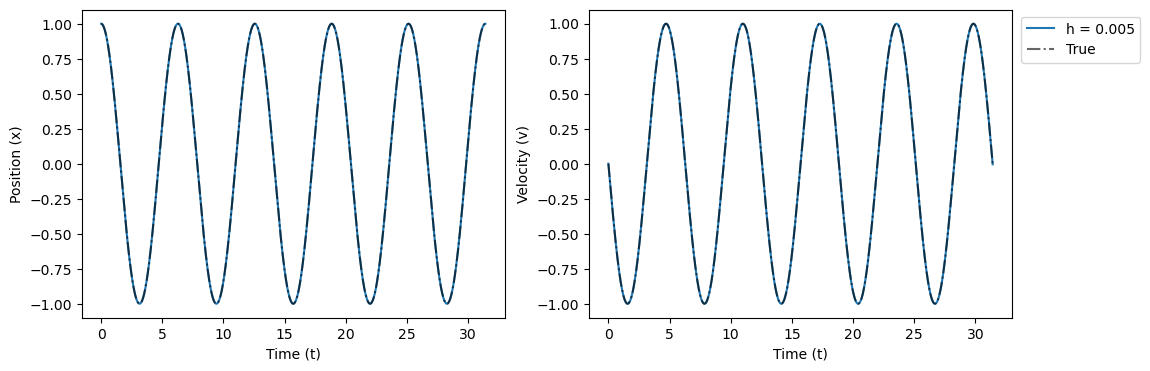

In [5]:
fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(121)
ax.plot(t_values, y_values[:,0], label='h = '+str(initial_h))
ax.plot(t_values, y_true(t_values, omega)[0], label='True', color='black', alpha = 0.6,linestyle='-.')
ax.set_xlabel('Time (t)')
ax.set_ylabel('Position (x)')

ax = fig.add_subplot(122)
ax.plot(t_values, y_values[:,1], label='h = '+ str(initial_h))
ax.plot(t_values, y_true(t_values, omega)[1], label='True', color='black', alpha = 0.6,linestyle='-.')
ax.set_xlabel('Time (t)')
ax.set_ylabel('Velocity (v)')
ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1))
plt.show()

#### b) Convergence vs analytic solution

For different stepsizes, compute the maximum absolute error E(h). Then, produce a log-log plot E(h) vs h, verifying that the slope p is $\sim$ 4.

In [6]:
h_steps = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]
time_results = []
y_results = []
y0 = np.array([1.0, 0.0])  
t0 = 0.0                   
tf = 10*np.pi                 
for h in h_steps:
    print(f"Running with step size h = {h}")
    t_values = [t0]
    y_values = [y0]
    t = t0
    y = y0

    #Time integration with constant step size
    while t < tf:
        yn1 = runge_kutta(t, y, h, omega)
        y_values.append(yn1)
        t += h
        t_values.append(t)
        y = yn1

    time_results.append(np.array(t_values))
    y_results.append(np.array(y_values))

Running with step size h = 0.5
Running with step size h = 0.2
Running with step size h = 0.1
Running with step size h = 0.05
Running with step size h = 0.02
Running with step size h = 0.01


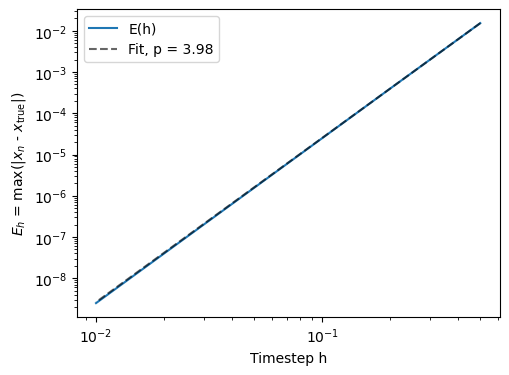

In [7]:
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(121)

E_h = []
for i in range(len(h_steps)):
    h = h_steps[i]
    t_values = time_results[i]
    y_values = y_results[i]
    y_true_values = y_true(t_values, omega)[0]
    E_h.append(np.max(np.abs(y_values[:,0]-y_true_values)))

params, _ = curve_fit(model, h_steps, E_h)
A_fit, p_fit = params

ax.plot(h_steps, E_h, label='E(h)')
ax.plot(h_steps, model(h_steps, A_fit, p_fit), label=r'Fit, p = ' +str(np.round(p_fit, 2)), color = 'black', alpha = 0.6, linestyle = '--')
ax.set_xlabel('Timestep h')
ax.set_ylabel(r'$E_h$ = max(|$x_{n}$ - $x_{\mathrm{true}}$|)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper left')
plt.show()

#### c) Self-convergence from three solutions

Pick three step sizes in ratio 1, 1/2, 1/4. Evaluate the Richardson ratio at $t = 10 \pi$ and confirm the estimated order is $\sim$ 4.

In [ ]:
h_convergence = [tf/100, tf/200, tf/400]    #to obtain the same final step
time_results = []
y_results = []
y0 = np.array([1.0, 0.0])  
t0 = 0.0                   
tf = 10*np.pi   

for h in h_convergence:
    print(f"Running with step size h = {h}")
    t_values = [t0]
    y_values = [y0]
    t = t0
    y = y0

    #Time integration with constant step size
    while t < tf:
        yn1 = runge_kutta(t, y, h, omega)
        #y_values.append(yn1)
        t += h
        t_values.append(t)
        y = yn1
    time_results.append(t)
    y_results.append(y[0])

N = np.log2(np.abs((y_results[0] - y_results[1])/(y_results[2] - y_results[1])))
print('-----------------------------------------')
print('Convergence order N:', N)

Running with step size h = 0.3141592653589793
Running with step size h = 0.15707963267948966
Running with step size h = 0.07853981633974483
-----------------------------------------
Convergence order N: 4.991658069562003
